In [26]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [27]:
df = pd.read_csv('GBPUSD_M15_20241030.csv', parse_dates=["Date"], index_col=0)

In [28]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)

# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
#     np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
# )

# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']), 1,
#     np.where((df['stoch_k'] < df['stoch_d']), -1, 0)
# )

# df["rsi"] = ta.rsi(df["Close"], length=13)
# rsi_upper = 70
# rsi_lower = 30
# df["position_rsi"] = np.where(df.rsi > rsi_upper, -1, np.nan) # 1. overbought -> go short
# df["position_rsi"] = np.where(df.rsi < rsi_lower, 1, df.position_rsi) # 2. oversold -> go long
# df.position_rsi = df.position_rsi.fillna(0) # 3. where 1 & 2 isn´t applicable -> neutral

# df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
# df['distance'] = df['Close'] - df['mid']
# df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
# df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
# df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
# df["position"] = df.position.ffill().fillna(0)

# df["sma"] = df['Close'].rolling(8).mean() - df['Close'].rolling(21).mean()
# df["min"] = df ['Close'].rolling(21).min() / df['Close'] - 1
# df["max"] = df['Close'].rolling(21).max() / df['Close'] - 1
# df["boll"] = (df['Close'] - df['Close'].rolling(21).mean()) / df['Close'].rolling(21).std()
# df['momentoum'] = df["returns"].rolling(8).sum() / df["returns"].rolling(8).std()
# df['jump'] = df["returns"].rolling(8).mean() - df["returns"].rolling(21).mean()
# df['jump_2'] = df['jump'] / df["returns"].rolling(21).std()

df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# ADX and Bollinger Bands combined signal strategy without ML confirmation
df[["adx", "plus_di", "minus_di"]] = ta.adx(df["High"], df["Low"], df["Close"], length=13)
df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
# df['adx_prev'] = df['adx'].shift(1)

# ADX above 25: DI crossover signal
df['position'] = np.where(
    (df['adx'] > 25) & (df['plus_di'] > df['minus_di']), 1, 
    np.where((df['adx'] > 25) & (df['plus_di'] < df['minus_di']), -1, np.nan)
)

# ADX <= 25: Bollinger Bands signal
df['position'] = np.where(
    (df['adx'] <= 25) & (df['Close'] < df['lower']), 1, 
    np.where((df['adx'] <= 25) & (df['Close'] > df['upper']), -1,
             np.where((df['adx'] <= 25) & (df.distance * df.distance.shift(1) < 0), 0, df["position"]))
)

df['position'] = df['position'].ffill().fillna(0)

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [ ]:
# df_filtered = df[((df['position'] == 1) & (df['position_rsi'] == 1)) | ((df['position'] == -1) & (df['position_rsi'] == -1))].copy()

In [ ]:
# df_filtered['position'] = df_filtered['position'].map({-1: 0, 1: 1})
# df.dropna(inplace=True)
# accuracy = accuracy_score(df_filtered.target, df_filtered.position) * 100
# accuracy

52.68781669971359

In [29]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [30]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

lr_clf = LogisticRegression(random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 53.74
Test Accuracy: 52.08
Total Accuracy: 53.40


In [10]:
G_wlr_th = 0.985
G_raw_accuracy_th = 52
G_filtered_accuracy_th = 54
G_sharp_ratio_th = 7.5
G_max_dd_th = 0.07
G_position_count_th = 24000
G_cumulative_th = 2.2
G_annual_th = 0.79

In [11]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': G_wlr_th,
    'raw_accuracy': G_raw_accuracy_th,
    'filtered_accuracy': G_filtered_accuracy_th,
    'sharp_ratio': G_sharp_ratio_th,
    'max_dd': G_max_dd_th,
    'position_count': G_position_count_th,
    'cumulative': G_cumulative_th,
    'annual' : G_annual_th}
joblib.dump(objects_to_save, 'U_G.joblib')

['U_G.joblib']

# Filter and Evaluations

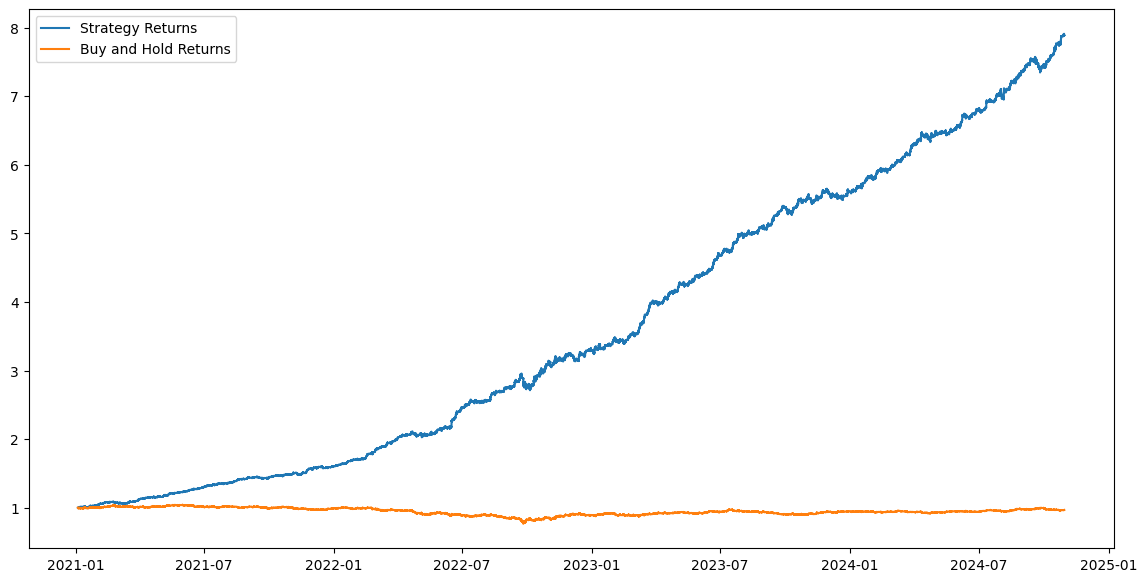

In [31]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [32]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.56
Annualized Sharpe Ratio: 5.94
Maximum Drawdown: -0.09


In [33]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    46499
1    45631
Name: count, dtype: int64
pred
-1    48446
 1    43684
Name: count, dtype: int64
position
-1.0    34126
 1.0    30056
 0.0    27948
Name: count, dtype: int64


In [34]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.98686185)

In [35]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,92130.000000,92130.000000,92130.000000,92130.000000,9.213000e+04,92130.000000,9.213000e+04,92130.000000,92130.000000,92130.000000,...,92130.000000,92130.000000,92130.000000,92130.000000,92130.000000,92130.000000,92130.000000,42471.000000,48591.000000,92130.000000
mean,1.284151,1.284618,1.283683,1.284152,-3.684904e-07,0.495289,-4.865469e-07,0.948440,0.000465,-0.000320,...,-0.044177,-0.051688,0.500109,0.499891,0.518542,0.000022,3.597286,0.000377,0.000372,0.030675
std,0.072044,0.071958,0.072122,0.072044,5.980452e-04,0.499981,5.964286e-04,0.050268,0.000379,1.027509,...,0.833488,0.998669,0.022692,0.022692,0.013080,0.000596,2.078651,0.000494,0.000446,0.026335
min,1.039630,1.051090,1.035180,1.039880,-3.298461e-02,0.000000,-3.298461e-02,0.766858,0.000028,-5.165244,...,-1.000000,-1.000000,0.349398,0.354508,0.500001,-0.032985,0.994875,0.000007,0.000007,-0.006654
25%,1.235290,1.235770,1.234830,1.235290,-2.411008e-04,0.000000,-2.383298e-04,0.915326,0.000239,-0.693959,...,-1.000000,-1.000000,0.483042,0.482924,0.508634,-0.000215,1.587274,0.000103,0.000109,0.010726
50%,1.271900,1.272270,1.271530,1.271900,7.219278e-06,0.000000,0.000000e+00,0.945201,0.000375,0.012602,...,0.000000,-1.000000,0.501639,0.498361,0.517013,0.000024,3.173367,0.000241,0.000245,0.027595
75%,1.351647,1.352110,1.351218,1.351660,2.430032e-04,1.000000,2.401991e-04,0.993327,0.000576,0.697011,...,1.000000,1.000000,0.517076,0.516958,0.525780,0.000263,5.503690,0.000483,0.000481,0.045246
max,1.424210,1.424790,1.423990,1.424210,1.595260e-02,1.000000,1.595260e-02,1.044256,0.013195,4.155522,...,1.000000,1.000000,0.645492,0.650602,0.650602,0.011740,7.908699,0.032985,0.011740,0.296552


In [36]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [37]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 14:15:00,1.36691,1.36697,1.36446,1.36556,-0.000995,1,0.000527,1.000628,0.000487,-2.044051,...,1.0,1,0.462047,0.537953,0.537953,0.000527,1.000035,NaN,0.000527,0.069754
2021-01-04 14:45:00,1.36628,1.36696,1.36535,1.36538,-0.000659,0,-0.000059,0.999911,0.000538,-1.223671,...,1.0,1,0.472429,0.527571,0.527571,-0.000059,1.000635,0.000059,NaN,0.048853
2021-01-04 15:00:00,1.36539,1.36607,1.36491,1.36530,-0.000059,0,-0.001194,0.998718,0.000466,-0.125851,...,1.0,1,0.479012,0.520988,0.520988,-0.001194,0.999442,0.001194,NaN,0.035598
2021-01-04 15:15:00,1.36534,1.36559,1.36353,1.36367,-0.001194,0,-0.000931,0.997788,0.000538,-2.220473,...,1.0,1,0.467196,0.532804,0.532804,-0.000931,0.998511,0.000931,NaN,0.059389
2021-01-04 15:30:00,1.36367,1.36396,1.36131,1.36240,-0.000931,1,0.000617,0.998403,0.000559,-1.664655,...,1.0,1,0.474139,0.525861,0.525861,0.000617,0.999127,NaN,0.000617,0.045410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 19:45:00,1.30006,1.30011,1.29923,1.29972,-0.000254,1,0.000015,0.967717,0.000704,-0.360318,...,1.0,1,0.492793,0.507207,0.507207,0.000015,7.880860,NaN,0.000015,0.007853
2024-10-29 20:15:00,1.29977,1.29993,1.29924,1.29928,-0.000354,1,0.000608,0.967963,0.000551,-0.642085,...,1.0,1,0.482771,0.517229,0.517229,0.000608,7.888445,NaN,0.000608,0.028031
2024-10-29 21:00:00,1.30063,1.30073,1.30033,1.30039,-0.000200,0,-0.000092,0.968112,0.000482,-0.414963,...,1.0,1,0.495896,0.504104,0.504104,-0.000092,7.885775,0.000092,NaN,0.001606


In [38]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

53.33514560467566

In [39]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    14810
1    14619
Name: count, dtype: int64
pred
0    16543
1    12886
Name: count, dtype: int64
position
-1.0    16543
 1.0    12886
Name: count, dtype: int64


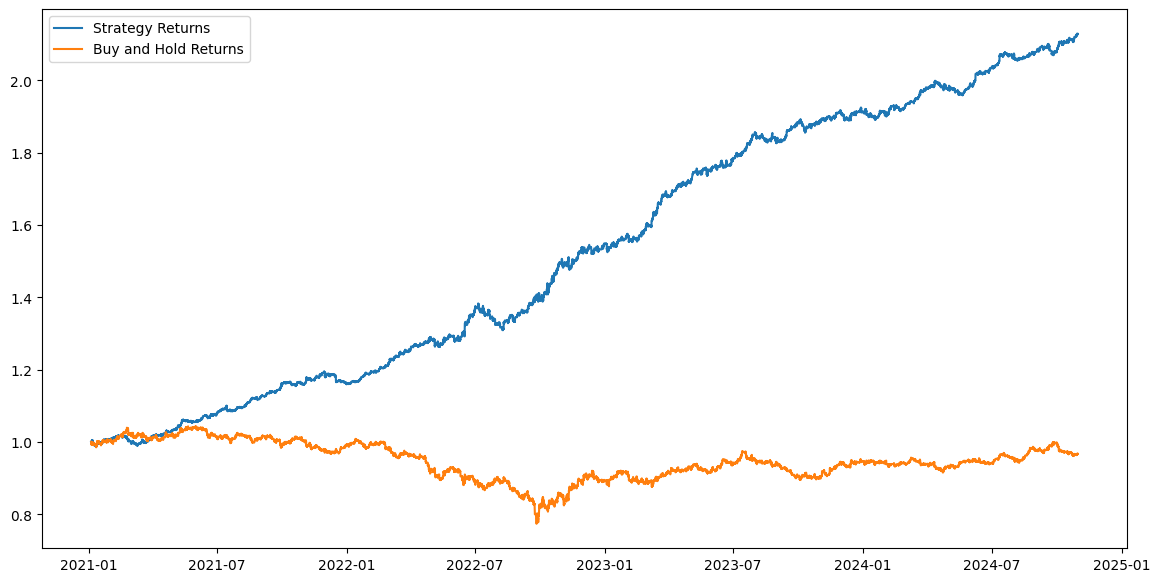

In [40]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [41]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.64
Annualized Sharpe Ratio: 6.67
Maximum Drawdown: -0.06


In [42]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(1.00358139)

In [43]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,...,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,13610.000000,15508.000000,29429.000000
mean,1.283956,1.284469,1.283464,1.283978,0.000016,0.496755,0.000004,0.948250,0.000489,0.055965,...,-0.124265,-0.124265,0.500807,0.499193,0.517722,0.000026,1.522142,0.000387,0.000388,0.037164
std,0.072864,0.072772,0.072956,0.072872,0.000657,0.499998,0.000609,0.050900,0.000394,1.095391,...,0.992266,0.992266,0.022092,0.022092,0.013215,0.000608,0.366608,0.000482,0.000466,0.026382
min,1.039630,1.051090,1.035180,1.049660,-0.015785,0.000000,-0.009689,0.774044,0.000028,-4.981047,...,-1.000000,-1.000000,0.349398,0.358356,0.500002,-0.015953,0.987716,0.000007,0.000007,0.001788
25%,1.235290,1.235870,1.234730,1.235320,-0.000278,0.000000,-0.000248,0.915054,0.000249,-0.724894,...,-1.000000,-1.000000,0.485204,0.483522,0.507829,-0.000228,1.171240,0.000111,0.000115,0.017415
50%,1.271790,1.272260,1.271420,1.271860,0.000037,0.000000,0.000000,0.945075,0.000396,0.121097,...,-1.000000,-1.000000,0.503093,0.496907,0.515724,0.000024,1.500640,0.000254,0.000258,0.033176
75%,1.353150,1.353580,1.352700,1.353180,0.000310,1.000000,0.000257,0.993750,0.000608,0.828848,...,1.000000,1.000000,0.516478,0.514796,0.524723,0.000277,1.890787,0.000498,0.000500,0.051142
max,1.424210,1.424540,1.423890,1.423920,0.015953,1.000000,0.015953,1.044175,0.013195,3.304080,...,1.000000,1.000000,0.641644,0.650602,0.650602,0.011585,2.128910,0.015953,0.011585,0.302450


In [44]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:00:00,1.36808,1.36855,1.36797,1.36841,0.000241,1,0.000848,1.003035,0.000423,0.570333,...,0.0,-1,0.510158,0.489842,0.510158,-0.000848,0.999153,0.000848,NaN,0.013795
2021-01-04 09:15:00,1.36840,1.36974,1.36840,1.36957,0.000848,0,-0.000307,1.002727,0.000505,1.677083,...,0.0,-1,0.534543,0.465457,0.534543,0.000307,0.999459,NaN,0.000307,0.062889
2021-01-04 09:30:00,1.36957,1.37022,1.36876,1.36915,-0.000307,1,0.000285,1.003013,0.000455,-0.674525,...,0.0,1,0.486459,0.513541,0.513541,0.000285,0.999744,NaN,0.000285,0.020605
2021-01-04 09:45:00,1.36914,1.36997,1.36855,1.36954,0.000285,0,-0.000679,1.002332,0.000454,0.627240,...,0.0,-1,0.522896,0.477104,0.522896,0.000679,1.000423,NaN,0.000679,0.039441
2021-01-04 10:00:00,1.36954,1.37024,1.36786,1.36861,-0.000679,0,-0.000745,1.001585,0.000521,-1.302381,...,0.0,1,0.476038,0.523962,0.523962,-0.000745,0.999678,0.000745,NaN,0.041586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 22:45:00,1.30056,1.30137,1.30056,1.30119,0.000484,0,-0.000038,0.968760,0.000207,2.343322,...,1.0,-1,0.519799,0.480201,0.519799,0.000038,7.888139,NaN,0.000038,0.033205
2024-10-29 23:15:00,1.30120,1.30145,1.30114,1.30114,-0.000038,0,-0.000354,0.968417,0.000185,-0.207258,...,1.0,-1,0.524343,0.475657,0.524343,0.000354,7.890929,NaN,0.000354,0.042353
2024-10-29 23:30:00,1.30089,1.30099,1.30067,1.30068,-0.000354,1,0.000062,0.968477,0.000235,-1.505083,...,1.0,1,0.466759,0.533241,0.533241,0.000062,7.891414,NaN,0.000062,0.060267


In [45]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy

53.33514560467566

In [46]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 14:15:00,1.36691,1.36697,1.36446,1.36556,-0.000995,1,0.000527,1.000628,0.000487,-2.044051,...,1.0,1,0.462047,0.537953,0.537953,0.000527,1.000527,NaN,0.000527,0.077554
2021-01-04 14:45:00,1.36628,1.36696,1.36535,1.36538,-0.000659,0,-0.000059,0.999911,0.000538,-1.223671,...,1.0,1,0.472429,0.527571,0.527571,-0.000059,1.000469,0.000059,NaN,0.056829
2021-01-04 15:00:00,1.36539,1.36607,1.36491,1.36530,-0.000059,0,-0.001194,0.998718,0.000466,-0.125851,...,1.0,1,0.479012,0.520988,0.520988,-0.001194,0.999275,0.001194,NaN,0.043685
2021-01-04 15:15:00,1.36534,1.36559,1.36353,1.36367,-0.001194,0,-0.000931,0.997788,0.000538,-2.220473,...,1.0,1,0.467196,0.532804,0.532804,-0.000931,0.998345,0.000931,NaN,0.067276
2021-01-04 15:30:00,1.36367,1.36396,1.36131,1.36240,-0.000931,1,0.000617,0.998403,0.000559,-1.664655,...,1.0,1,0.474139,0.525861,0.525861,0.000617,0.998961,NaN,0.000617,0.053415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 19:45:00,1.30006,1.30011,1.29923,1.29972,-0.000254,1,0.000015,0.967717,0.000704,-0.360318,...,1.0,1,0.492793,0.507207,0.507207,0.000015,2.126651,NaN,0.000015,0.016172
2024-10-29 20:15:00,1.29977,1.29993,1.29924,1.29928,-0.000354,1,0.000608,0.967963,0.000551,-0.642085,...,1.0,1,0.482771,0.517229,0.517229,0.000608,2.127944,NaN,0.000608,0.036181
2024-10-29 21:00:00,1.30063,1.30073,1.30033,1.30039,-0.000200,0,-0.000092,0.968112,0.000482,-0.414963,...,1.0,1,0.495896,0.504104,0.504104,-0.000092,2.127748,0.000092,NaN,0.009977


In [47]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(1.00358139)

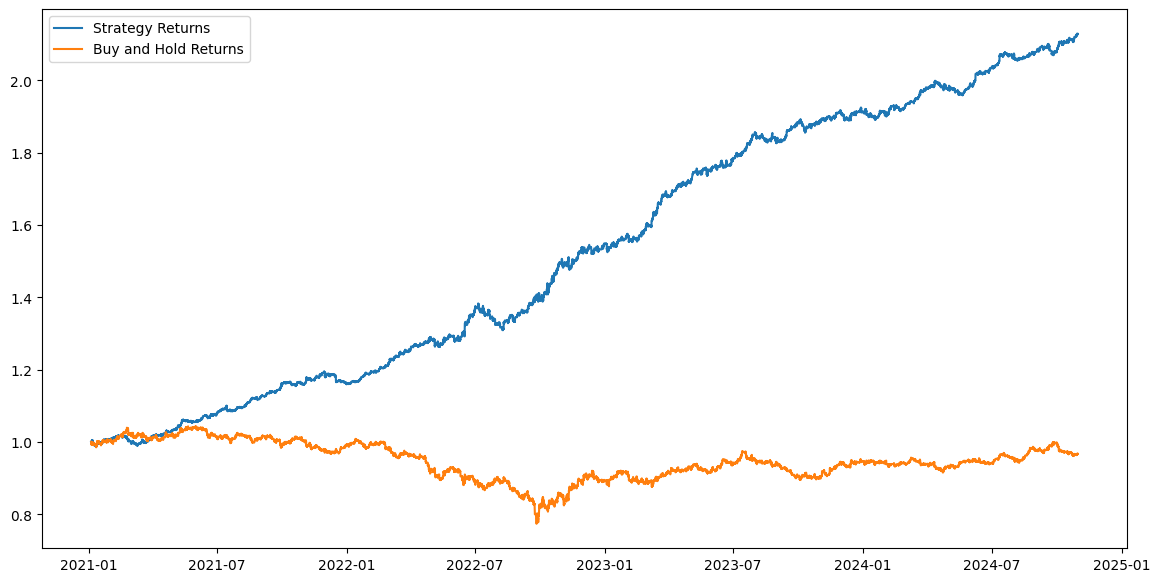

In [48]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [49]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.64
Annualized Sharpe Ratio: 6.67
Maximum Drawdown: -0.06


In [50]:
df_filtered_2.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,position,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,...,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,29429.000000,13610.000000,15508.000000,29429.000000
mean,1.283956,1.284469,1.283464,1.283978,0.000016,0.496755,0.000004,0.948250,0.000489,0.055965,...,-0.124265,-0.124265,0.500807,0.499193,0.517722,0.000026,1.522142,0.000387,0.000388,0.037164
std,0.072864,0.072772,0.072956,0.072872,0.000657,0.499998,0.000609,0.050900,0.000394,1.095391,...,0.992266,0.992266,0.022092,0.022092,0.013215,0.000608,0.366608,0.000482,0.000466,0.026382
min,1.039630,1.051090,1.035180,1.049660,-0.015785,0.000000,-0.009689,0.774044,0.000028,-4.981047,...,-1.000000,-1.000000,0.349398,0.358356,0.500002,-0.015953,0.987716,0.000007,0.000007,0.001788
25%,1.235290,1.235870,1.234730,1.235320,-0.000278,0.000000,-0.000248,0.915054,0.000249,-0.724894,...,-1.000000,-1.000000,0.485204,0.483522,0.507829,-0.000228,1.171240,0.000111,0.000115,0.017415
50%,1.271790,1.272260,1.271420,1.271860,0.000037,0.000000,0.000000,0.945075,0.000396,0.121097,...,-1.000000,-1.000000,0.503093,0.496907,0.515724,0.000024,1.500640,0.000254,0.000258,0.033176
75%,1.353150,1.353580,1.352700,1.353180,0.000310,1.000000,0.000257,0.993750,0.000608,0.828848,...,1.000000,1.000000,0.516478,0.514796,0.524723,0.000277,1.890787,0.000498,0.000500,0.051142
max,1.424210,1.424540,1.423890,1.423920,0.015953,1.000000,0.015953,1.044175,0.013195,3.304080,...,1.000000,1.000000,0.641644,0.650602,0.650602,0.011585,2.128910,0.015953,0.011585,0.302450
